## Presentado por:

## Esteban Garcia Otalvaro
## Fabian Andres Posso

In [12]:
import scipy
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal




**CONSTRUCCIÓN Y GRAFICACIÓN DE SEÑALES EN EL TIEMPO:**


a) Construya una señal cuadrada periódica, definiendo su frecuencia fundamental, amplitud y
número de muestras.


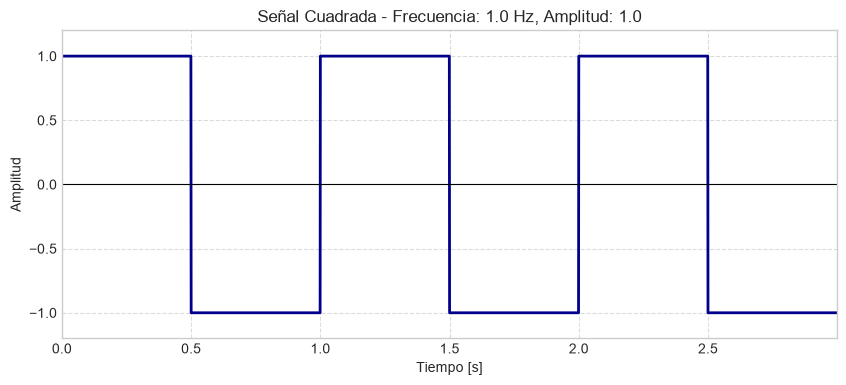

In [13]:
# 1. Parámetros definidos
f0 = 1.0           # Frecuencia fundamental (Hz)
T0 = 1.0 / f0      # Período fundamental (s)
A = 1.0            # Amplitud

# 2. Parámetros de muestreo (Ajustados para alta resolución)
fs = 1000.0        # Frecuencia de muestreo (Hz) - Alta para bordes definidos
N = 3000           # Número de muestras (3 segundos = 3 períodos exactos)

# 3. Construcción del vector de tiempo discreto
t = np.arange(N) / fs

# 4. Generación de la señal cuadrada
# signal.square genera una onda entre -1 y 1. Se multiplica por la amplitud 'A'.
senal_cuadrada = A * signal.square(2 * np.pi * f0 * t)

# 5. Visualización
plt.figure(figsize=(10, 4))
plt.plot(t, senal_cuadrada, color='darkblue', linewidth=2)
plt.title(f"Señal Cuadrada - Frecuencia: {f0} Hz, Amplitud: {A}")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, max(t))
plt.ylim(-A * 1.2, A * 1.2)
plt.show()

b) Construya una señal triangular periódica, con la misma frecuencia fundamental, amplitud y
número de muestras que la señal anterior.

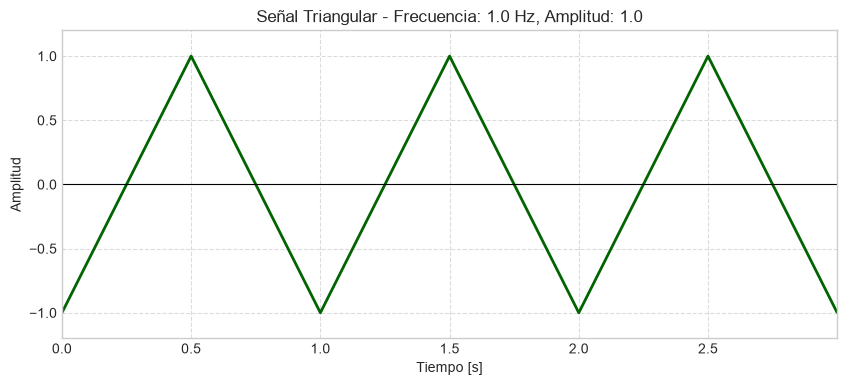

In [14]:
# 1. Parámetros idénticos a los de la señal cuadrada
f0 = 1.0           # Frecuencia fundamental (Hz)
A = 1.0            # Amplitud
fs = 1000.0        # Frecuencia de muestreo (Hz)
N = 3000           # Número de muestras (3 ciclos exactos)

# 2. Vector de tiempo
t = np.arange(N) / fs

# 3. Generación de la señal triangular
# signal.sawtooth genera una onda triangular simétrica cuando width=0.5
senal_triangular = A * signal.sawtooth(2 * np.pi * f0 * t, width=0.5)

# 4. Visualización
plt.figure(figsize=(10, 4))
plt.plot(t, senal_triangular, color='darkgreen', linewidth=2)
plt.title(f"Señal Triangular - Frecuencia: {f0} Hz, Amplitud: {A}")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.axhline(0, color='black', linewidth=0.8, linestyle='-')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, max(t))
plt.ylim(-A * 1.2, A * 1.2)
plt.show()

c) Grafique ambas señales en el dominio del tiempo.

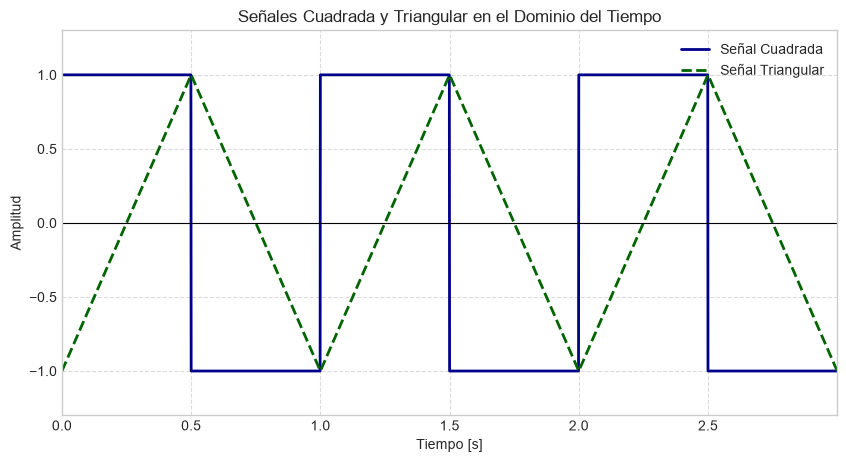

In [19]:
# 1. Visualización conjunta
plt.figure(figsize=(10, 5))

2# Trazado de ambas señales en los mismos ejes para comparar su alineación
plt.plot(t, senal_cuadrada, label='Señal Cuadrada', color='darkblue', linewidth=2)
plt.plot(t, senal_triangular, label='Señal Triangular', color='darkgreen', linewidth=2, linestyle='--')

plt.title("Señales Cuadrada y Triangular en el Dominio del Tiempo")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.axhline(0, color='black', linewidth=0.8)
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, max(t))
plt.ylim(-A * 1.3, A * 1.3)
plt.show()

d) Cree una función que reciba una señal periódica, y devuelva sus coeficientes de la serie de Fourier
(forma exponencial), calculados mediante NumPy.


In [20]:
def coeficientes_fourier_exponencial(senal, t, f0, num_armonicos):
    """
    Calcula los coeficientes de la serie de Fourier en forma exponencial 
    mediante operaciones vectorizadas (sin bucles).
    """
    # Vector de índices de armónicos: [-N, ..., 0, ..., N]
    n = np.arange(-num_armonicos, num_armonicos + 1)
    
    # Matriz de fase mediante Broadcasting de NumPy
    # n[:, None] transpone 'n' a columna (Kx1) y 't' es fila (1xM), resultando en matriz (KxM)
    fase = -1j * 2 * np.pi * f0 * n[:, None] * t
    
    # Sumatoria a lo largo del eje del tiempo (axis=1) normalizada por el número de muestras
    # Equivale numéricamente a: (1/T) * integral(senal * exp(-j*w0*n*t) dt)
    cn = np.sum(senal * np.exp(fase), axis=1) / len(t)
    
    return n, cn

# --- Comprobación con los datos del inciso anterior ---
# Se calculan los coeficientes para los primeros 5 armónicos de la señal cuadrada
n_indices, c_n = coeficientes_fourier_exponencial(senal_cuadrada, t, f0=1.0, num_armonicos=5)

# Visualización en consola de las magnitudes para el componente DC y los armónicos positivos
print("Índice 'n' | Magnitud | Fase (rad)")
print("-" * 35)
for idx, n_val in enumerate(n_indices):
    if n_val >= 0:  # Mostrar solo DC y armónicos positivos por simetría
        magnitud = np.abs(c_n[idx])
        fase_rad = np.angle(c_n[idx])
        print(f"n = {n_val:2d}   |  {magnitud:.4f}  | {fase_rad:>7.4f}")


Índice 'n' | Magnitud | Fase (rad)
-----------------------------------
n =  0   |  0.0000  |  0.0000
n =  1   |  0.6366  | -1.5677
n =  2   |  0.0000  |  0.0000
n =  3   |  0.2122  | -1.5614
n =  4   |  0.0000  |  0.7854
n =  5   |  0.1273  | -1.5551


**APLICACIÓN DE LA FUNCIÓN obtener_coefientes_fourier(f) A LAS SEÑALES CUADRADA Y TRIANGULAR:**

e) Aplique la función anterior a la señal cuadrada y a la señal triangular, y obtenga sus respectivos
coeficientes

In [21]:
# 1. Definición de la resolución espectral
num_armonicos = 15

# 2. Estructuración de datos para procesamiento iterativo
senales = {
    "Cuadrada": senal_cuadrada,
    "Triangular": senal_triangular
}

# 3. Cálculo de coeficientes vectorizado mediante Dictionary Comprehension
# Se ejecuta la función para ambas señales en una sola línea de código
coeficientes = {
    nombre: coeficientes_fourier_exponencial(senal, t, f0, num_armonicos) 
    for nombre, senal in senales.items()
}

# 4. Extracción y formateo simultáneo de resultados en consola
n_indices = coeficientes["Cuadrada"][0]
cn_cuadrada = coeficientes["Cuadrada"][1]
cn_triangular = coeficientes["Triangular"][1]

print(f"{'n':<4} | {'|Cn| Cuadrada':<15} | {'|Cn| Triangular':<15}")
print("-" * 38)

# Filtrar para imprimir solo la componente DC y los primeros 5 armónicos positivos
for i, n_val in enumerate(n_indices):
    if 0 <= n_val <= 5:
        mag_cuad = np.abs(cn_cuadrada[i])
        mag_tri = np.abs(cn_triangular[i])
        print(f"{n_val:<4} | {mag_cuad:<15.4f} | {mag_tri:<15.4f}")


n    | |Cn| Cuadrada   | |Cn| Triangular
--------------------------------------
0    | 0.0000          | 0.0000         
1    | 0.6366          | 0.4053         
2    | 0.0000          | 0.0000         
3    | 0.2122          | 0.0450         
4    | 0.0000          | 0.0000         
5    | 0.1273          | 0.0162         


f) Cree una función que reciba un conjunto de coeficientes de Fourier y grafique el espectro de
magnitud y el espectro de fase correspondientes.

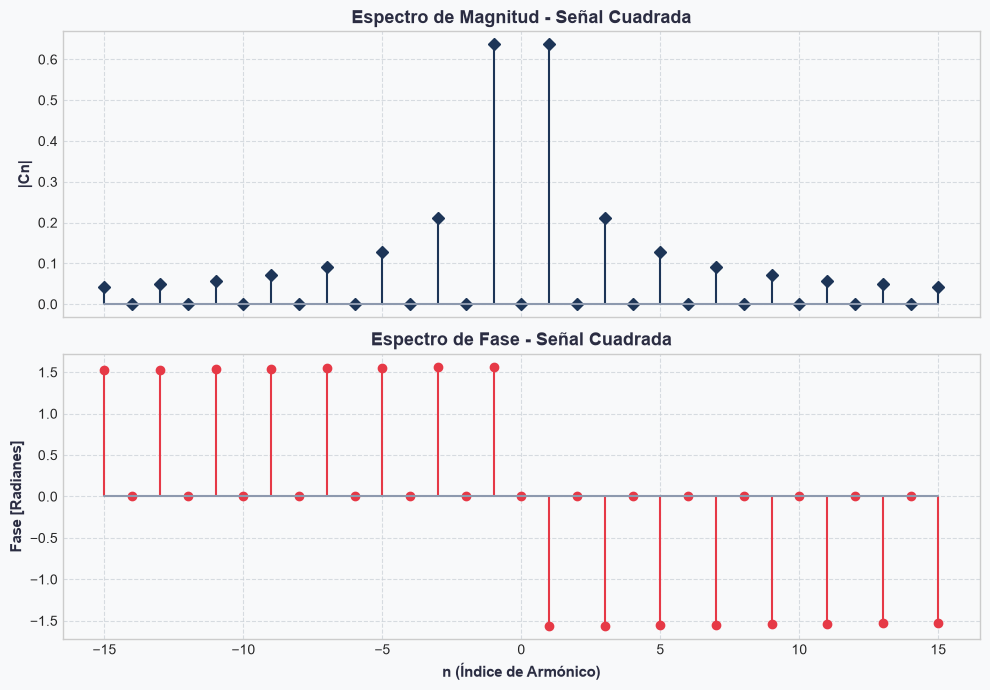

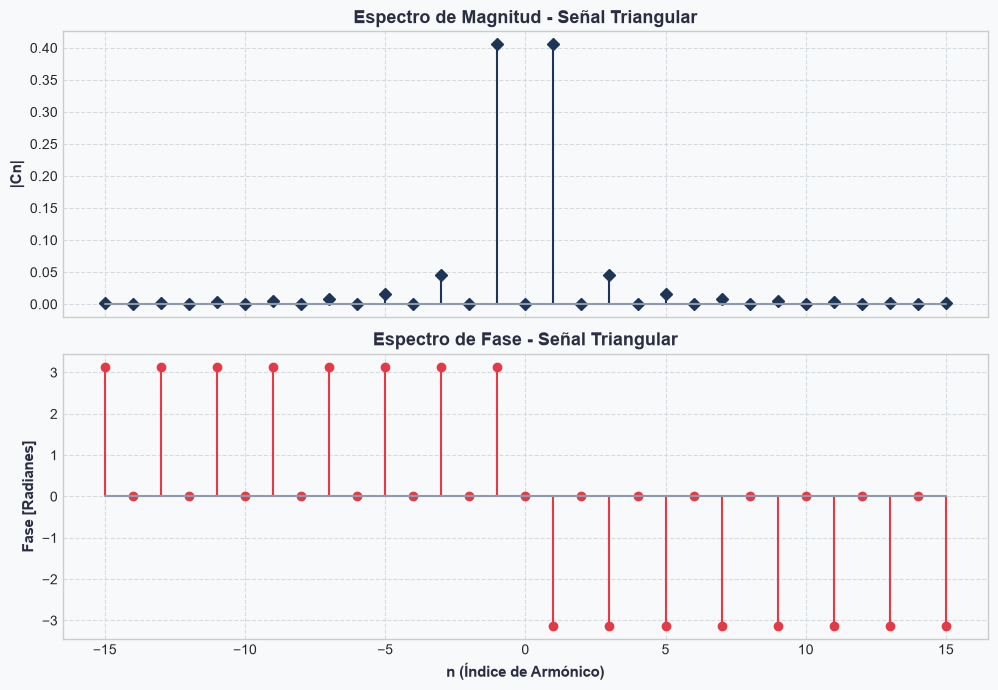

In [ ]:
def graficar_espectro(n, cn, titulo="Señal"):
    """
    Grafica los espectros discretos de magnitud y fase de una serie de Fourier.
    Incluye un filtro de umbral para suprimir ruido numérico en la fase.
    """
    # 1. Extracción de magnitud y fase
    magnitud = np.abs(cn)
    fase = np.angle(cn)
    
    # 2. Filtrado de ruido numérico (Optimización matemática)
    # Si la magnitud es prácticamente cero, forzamos la fase a 0 para evitar 
    # ángulos aleatorios generados por la imprecisión de punto flotante.
    fase[magnitud < 1e-10] = 0.0

    # 3. Configuración de la figura multipanel
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7), facecolor='#F8F9FA', sharex=True)
    
    # 4. Espectro de Magnitud
    ax1.set_facecolor('#F8F9FA')
    ax1.stem(n, magnitud, linefmt="#571D4A", markerfmt='D', basefmt='#8D99AE')
    ax1.set_title(f"Espectro de Magnitud - {titulo}", fontsize=13, fontweight='bold', color="#2D3377")
    ax1.set_ylabel("|Cn|", fontsize=11, fontweight='bold', color='#2B2D42')
    ax1.grid(True, linestyle='--', color='#CED4DA', alpha=0.8)
    
    # 5. Espectro de Fase
    ax2.set_facecolor('#F8F9FA')
    ax2.stem(n, fase, linefmt='#E63946', markerfmt='o', basefmt='#8D99AE')
    ax2.set_title(f"Espectro de Fase - {titulo}", fontsize=13, fontweight='bold', color='#2B2D42')
    ax2.set_xlabel("n (Índice de Armónico)", fontsize=11, fontweight='bold', color='#2B2D42')
    ax2.set_ylabel("Fase [Radianes]", fontsize=11, fontweight='bold', color='#2B2D42')
    ax2.grid(True, linestyle='--', color='#CED4DA', alpha=0.8)
    
    # 6. Ajuste de márgenes y renderizado
    plt.tight_layout()
    plt.show()

# --- Comprobación: Ejecución de la función con las señales previas ---
graficar_espectro(n_indices, cn_cuadrada, titulo="Señal Cuadrada")
graficar_espectro(n_indices, cn_triangular, titulo="Señal Triangular")

g) Grafique los espectros de magnitud y fase de la señal cuadrada y de la señal triangular

Generando espectros para la Señal Cuadrada...


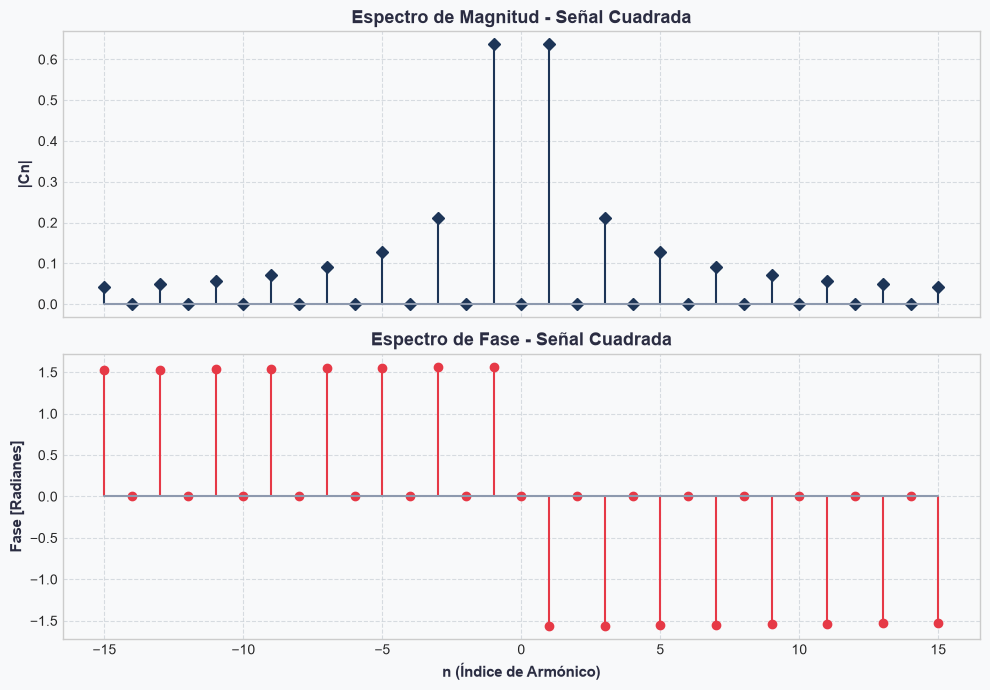

Generando espectros para la Señal Triangular...


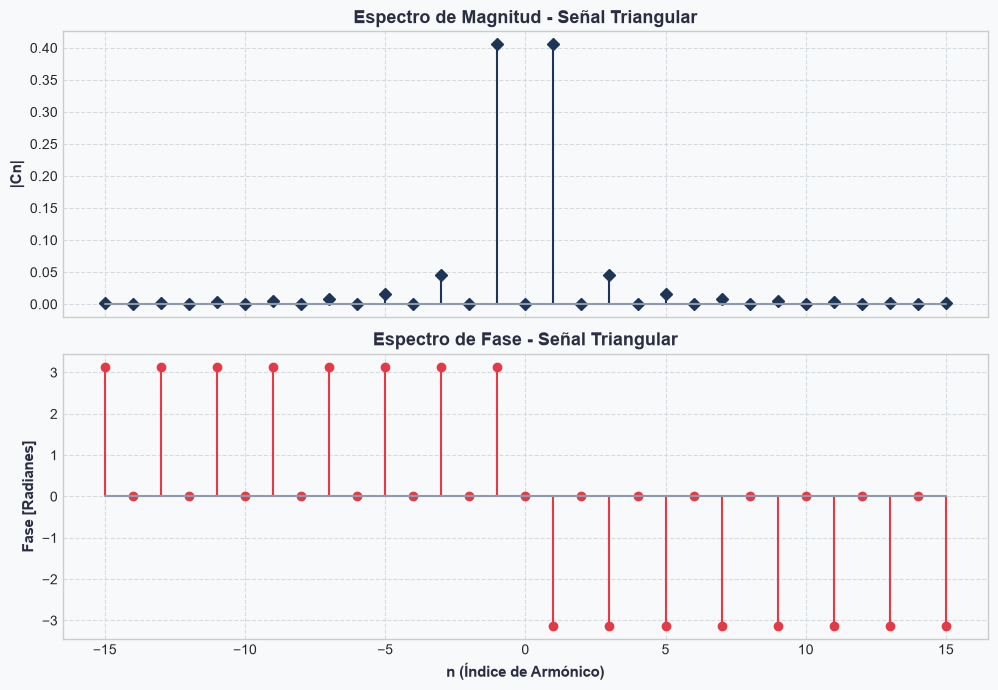

In [23]:
# Aplicación directa de la función creada en el inciso anterior
# Se asume que las variables n_indices, cn_cuadrada y cn_triangular ya están en memoria

print("Generando espectros para la Señal Cuadrada...")
graficar_espectro(n_indices, cn_cuadrada, titulo="Señal Cuadrada")

print("Generando espectros para la Señal Triangular...")
graficar_espectro(n_indices, cn_triangular, titulo="Señal Triangular")

**FUNCION PARA LA RECONSTRUCCIÓN PROGRESIVA DE LA SEÑAL CON SUS RESPECTIVAS GRAFICAS:**

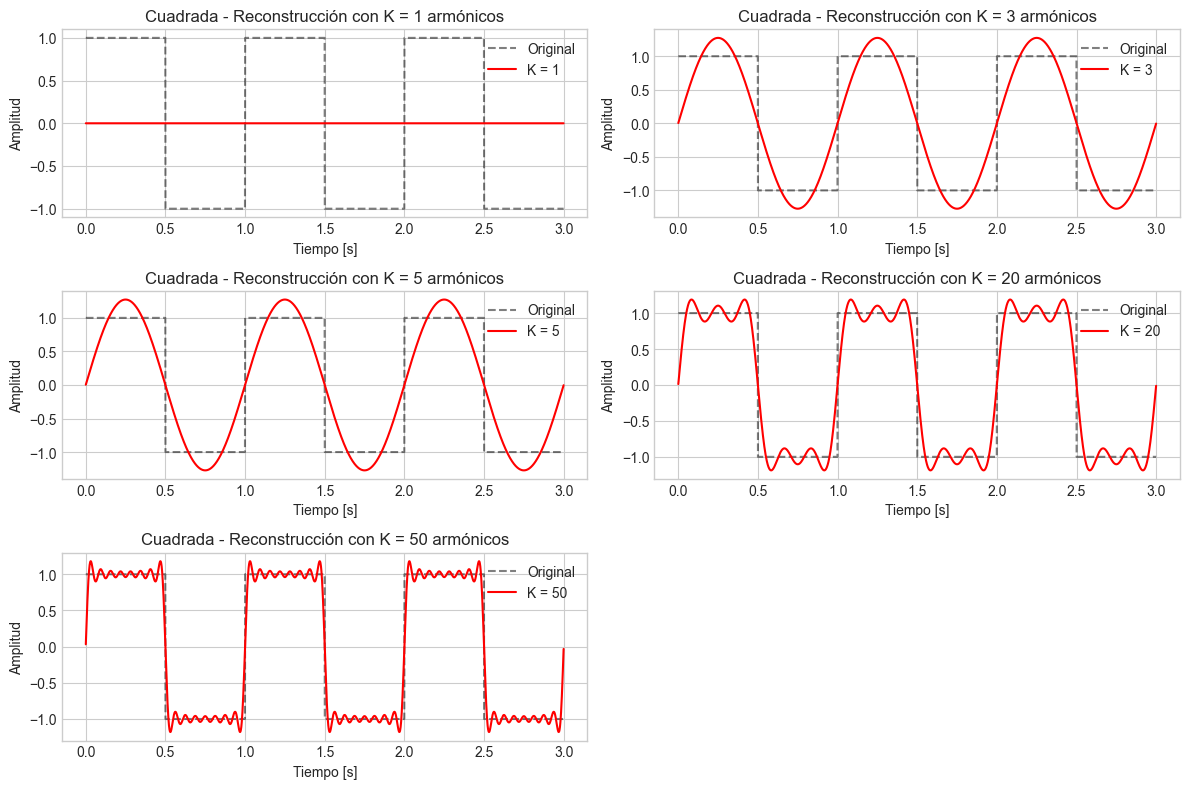

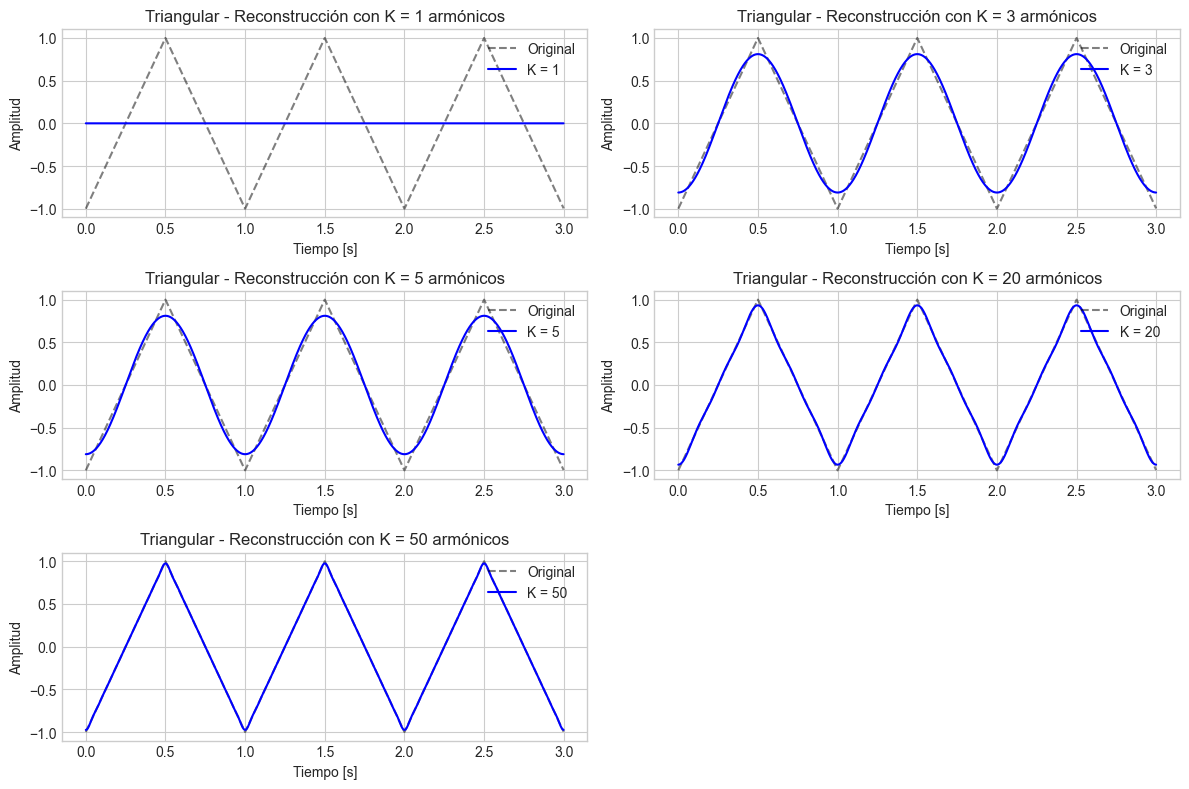

In [7]:
def reconstruir_senal(c_k, k_harmonics, K_armonicos):
    """
    Reconstruye la señal en el dominio del tiempo utilizando únicamente 
    armónicos en el rango [-K_armonicos, K_armonicos].
    """
    # Copiar coeficientes y enmascarar los armónicos de orden mayor a K
    c_k_filtrado = c_k.copy()
    c_k_filtrado[np.abs(k_harmonics) > K_armonicos] = 0.0
    
    # Deshacer el fftshift y aplicar IFFT multiplicando por N (para compensar la división inicial)
    c_k_ishifted = np.fft.ifftshift(c_k_filtrado)
    x_reconstruida = np.real(np.fft.ifft(c_k_ishifted) * len(c_k))
    
    return x_reconstruida

# i) Reconstruir con K = 1, 3, 5, 20, 50
armonicos = [1, 3, 5, 20, 50]

# Reconstrucción de la Señal Cuadrada
plt.figure(figsize=(12, 8))
for i, K in enumerate(armonicos, 1):
    x_rec = reconstruir_senal(c_k_cuadrada, k_cuadrada, K)
    plt.subplot(3, 2, i)
    plt.plot(t, x_cuadrada, 'k--', alpha=0.5, label='Original')
    plt.plot(t, x_rec, 'r', label=f'K = {K}')
    plt.title(f'Cuadrada - Reconstrucción con K = {K} armónicos')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')
    plt.legend(loc='upper right')
    plt.grid(True)

plt.tight_layout()
plt.show()

# Reconstrucción de la Señal Triangular
plt.figure(figsize=(12, 8))
for i, K in enumerate(armonicos, 1):
    x_rec = reconstruir_senal(c_k_triangular, k_triangular, K)
    plt.subplot(3, 2, i)
    plt.plot(t, x_triangular, 'k--', alpha=0.5, label='Original')
    plt.plot(t, x_rec, 'b', label=f'K = {K}')
    plt.title(f'Triangular - Reconstrucción con K = {K} armónicos')
    plt.xlabel('Tiempo [s]')
    plt.ylabel('Amplitud')
    plt.legend(loc='upper right')
    plt.grid(True)

plt.tight_layout()
plt.show()


**COMPORTAMIENTO DEL FENOMENO DE GIBBS TANTO EN LA SEÑAL CUADRADA COMO EN LA TRIANGULAR:**

El Fenómeno de Gibbs ocurre cuando se aproxima una señal periódica mediante una serie truncada de Fourier si la señal contiene discontinuidades de salto (como los bordes verticales de la onda cuadrada).

A medida que se incrementa el número de armónicos $K$ ($K=1, 3, 5, 20, 50$), las oscilaciones de la señal reconstruida se comprimen hacia el punto de discontinuidad. Sin embargo, la magnitud del sobrepico o rizado cerca del salto no tiende a cero, sino que se estabiliza en aproximadamente un $8.95\%$ de la altura de la discontinuidad, es decir, sin importar cuántos millones de armónicos se agreguen a la Serie de Fourier de una señal con discontinuidades, la amplitud del primer sobrepico nunca desaparecerá; siempre se estabilizará exactamente en un $8.95\%$ de la altura del salto discontinuo (propiedad conocida como la Constante de Wilbraham-Gibbs)

**ANALISIS ESPECTRAL DE UNA SEÑAL ECG:**

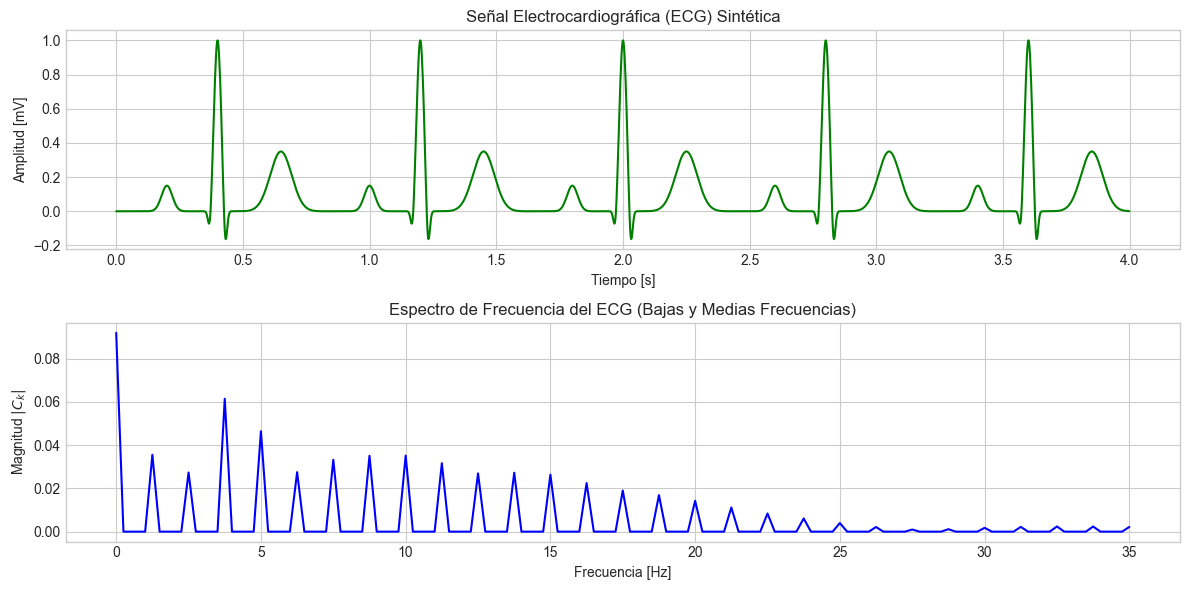

In [9]:
def generar_ecg_sintetico(t, hr=60):
    """
    Genera un ciclo cuasi-periódico de ECG sintético combinando gaussianas.
    """
    f_cardiac = hr / 60.0
    t_mod = np.mod(t, 1.0 / f_cardiac)
    
    # Ondas representadas como sumas de gaussianas
    p_wave = 0.15 * np.exp(-((t_mod - 0.2) / 0.03)**2)
    q_wave = -0.15 * np.exp(-((t_mod - 0.37) / 0.01)**2)
    qrs_wave = 1.0 * np.exp(-((t_mod - 0.40) / 0.02)**2)
    s_wave = -0.25 * np.exp(-((t_mod - 0.43) / 0.01)**2)
    t_wave = 0.35 * np.exp(-((t_mod - 0.65) / 0.06)**2)
    
    return p_wave + q_wave + qrs_wave + s_wave + t_wave

# Crear señal ECG sintética limpia
fs_ecg = 500  # Frecuencia de muestreo 500 Hz
t_ecg = np.linspace(0, 4, 4 * fs_ecg, endpoint=False)
x_ecg = generar_ecg_sintetico(t_ecg, hr=75)

# Coeficientes de Fourier y frecuencias
N_ecg = len(x_ecg)
X_ecg = np.abs(np.fft.fftshift(np.fft.fft(x_ecg) / N_ecg))
freqs_ecg = np.fft.fftshift(np.fft.fftfreq(N_ecg, d=1/fs_ecg))

# Graficar ECG en tiempo y su espectro de frecuencia
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6))

ax1.plot(t_ecg, x_ecg, 'g-', linewidth=1.5)
ax1.set_title('Señal Electrocardiográfica (ECG) Sintética')
ax1.set_xlabel('Tiempo [s]')
ax1.set_ylabel('Amplitud [mV]')
ax1.grid(True)

# Mostrar solo frecuencias positivas hasta 35 Hz
mask_ecg = (freqs_ecg >= 0) & (freqs_ecg <= 35)
ax2.plot(freqs_ecg[mask_ecg], X_ecg[mask_ecg], 'b-', linewidth=1.5)
ax2.set_title('Espectro de Frecuencia del ECG (Bajas y Medias Frecuencias)')
ax2.set_xlabel('Frecuencia [Hz]')
ax2.set_ylabel('Magnitud $|C_k|$')
ax2.grid(True)

plt.tight_layout()
plt.show()

La señal electrocardiográfica se compone de ondas asociadas a la despolarización y repolarización del tejido cardíaco, distribuidas en el dominio de la frecuencia de la siguiente forma:   

Onda P (Despolarización Auricular): Corresponde a deflexiones lentas y suaves. Sus componentes principales de frecuencia se ubican en el rango de $0.5 \text{ Hz} \text{ a } 10 \text{ Hz}$.   

Complejo QRS (Despolarización Ventricular): Corresponde al cambio de voltaje más rápido y abrupto en el tiempo. Al tener pendientes muy pronunciadas, requiere componentes espectrales de alta frecuencia, concentrando su energía entre $8 \text{ Hz} \text{ y } 40 \text{ Hz}$ (con un pico central alrededor de $10 \text{ Hz} - 15 \text{ Hz}$).   

Onda T (Repolarización Ventricular): Representa una variación lenta de voltaje al final del ciclo cardíaco. Sus frecuencias son muy bajas, situándose típicamente entre $0.5 \text{ Hz} \text{ y } 7 \text{ Hz}$.  